In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from torch.optim import AdamW
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report


In [68]:
pth = os.path.abspath(os.path.join(os.getcwd(), ".."))
pth = os.path.abspath(os.path.join(pth, "data"))
print(pth)  # Affiche le répertoire parent

c:\Users\DF6610\Challenge_tech\data


In [69]:
df_train = pd.read_csv(pth + "/augmented/train.csv")
df_val = pd.read_csv(pth + "/augmented/val.csv")
df_test = pd.read_csv(pth + "/augmented/test.csv")

In [70]:
label_mapping={'out_of_scope': 0,
 'translate': 1,
 'book_flight': 2,
 'lost_luggage': 3,
 'travel_alert': 4,
 'travel_suggestion': 5,
 'carry_on': 6,
 'book_hotel': 7,
 'flight_status': 8}

In [71]:
df_train_full = pd.concat([df_train, df_val], ignore_index=True)
X_train_full = df_train_full['text']
y_train_full = df_train_full['label'].map(label_mapping)
y_train = df_train['label'].map(label_mapping)

In [72]:
frequencies = dict(y_train.value_counts())
# Total des échantillons
total_samples = sum(frequencies.values())
# Calcul des poids inversés
weights = {key: total_samples / (freq * len(frequencies)) for key, freq in frequencies.items()}
# Appliquer un facteur de 2 à la classe 3 pour augmenter son poids
weights[3] *= 2
weights


{0: np.float64(0.4657878217200251),
 3: np.float64(1.6825396825396826),
 8: np.float64(1.1293759512937596),
 5: np.float64(1.1777777777777778),
 2: np.float64(1.1777777777777778),
 1: np.float64(1.230514096185738),
 6: np.float64(1.2491582491582491),
 4: np.float64(1.3515482695810566),
 7: np.float64(1.374074074074074)}

In [73]:
# Charger le tokenizer et le modèle DistilBERT multilingue
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-multilingual-cased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-multilingual-cased", num_labels=9)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [74]:
print(model)
# Afficher le modèle

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)

In [75]:
# Prétraitement des données

# Fonction de tokenisation
def tokenize_with_progress(data, desc):
    encodings = tokenizer(
        list(data),  # Convertir la colonne pandas en liste
        truncation=True,
        padding="max_length",  # Forcer la même longueur
        max_length=512,
        return_tensors="pt"  # Retourner directement un tenseur PyTorch
    )
    return {key: encodings[key] for key in encodings}


   

# Tokenisation avec barre de chargement
print("Tokenisation train...")
train_train_encodings = tokenize_with_progress(df_train.text, "Tokenisation train")
print("Tokenisation train ✅ ")

print("Tokenisation val...")
val_encodings = tokenize_with_progress(df_val.text, "Tokenisation val")
print("Tokenisation val ✅ ")
print("Tokenisation test...")
test_encodings = tokenize_with_progress(df_test.text, "Tokenisation test")
print("Tokenisation test ✅ ")



# Création du mappage des labels
label_mapping = {label: idx for idx, label in enumerate(df_train.label.unique())}
print("Map des labels ✅ ")

# Conversion des labels en tenseurs
train_train_labels = torch.tensor(df_train["label"].map(label_mapping).values, dtype=torch.long)
val_labels = torch.tensor(df_val["label"].map(label_mapping).values, dtype=torch.long)
test_labels = torch.tensor(df_test["label"].map(label_mapping).values, dtype=torch.long)
print("transformation en tenseurs ✅ ")

# Création des datasets
train_train_dataset = TensorDataset(train_train_encodings["input_ids"], train_train_encodings["attention_mask"], train_train_labels)
val_dataset = TensorDataset(val_encodings["input_ids"], val_encodings["attention_mask"], val_labels)
test_dataset = TensorDataset(test_encodings["input_ids"], test_encodings["attention_mask"], test_labels)
print("transformation en datasets ✅ ")

# Création des DataLoaders
train_train_dataloader = DataLoader(train_train_dataset, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
print("transformation en dataloaders ✅ ")

print("Données prétraitées ✅ ")

Tokenisation train...
Tokenisation train ✅ 
Tokenisation val...
Tokenisation val ✅ 
Tokenisation test...
Tokenisation test ✅ 
Map des labels ✅ 
transformation en tenseurs ✅ 
transformation en datasets ✅ 
transformation en dataloaders ✅ 
Données prétraitées ✅ 


In [76]:
for param in model.distilbert.parameters():
    param.requires_grad = True  #

In [77]:
# Initialiser l'optimizer (AdamW est souvent utilisé pour les modèles Transformers)
optimizer = AdamW(model.parameters(), lr=5e-5)

In [78]:
weights

{0: np.float64(0.4657878217200251),
 3: np.float64(1.6825396825396826),
 8: np.float64(1.1293759512937596),
 5: np.float64(1.1777777777777778),
 2: np.float64(1.1777777777777778),
 1: np.float64(1.230514096185738),
 6: np.float64(1.2491582491582491),
 4: np.float64(1.3515482695810566),
 7: np.float64(1.374074074074074)}

In [79]:
# Fonction de perte pour la classification
# Définir les poids pour chaque classe 

# Créer un tensor de taille 9 (le nombre total de classes) et initialiser à zéro
class_weights_tensor = torch.zeros(9, dtype=torch.float32)

# Remplir le tensor avec les poids du dictionnaire en utilisant les clés comme indices
for class_idx, weight in weights.items():
    class_weights_tensor[class_idx] = torch.tensor(weight, dtype=torch.float32)

# Afficher les poids pour vérifier
print(class_weights_tensor)
# Définir la fonction de perte pondérée
#loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)


weights

tensor([0.4658, 1.2305, 1.1778, 1.6825, 1.3515, 1.1778, 1.2492, 1.3741, 1.1294])


{0: np.float64(0.4657878217200251),
 3: np.float64(1.6825396825396826),
 8: np.float64(1.1293759512937596),
 5: np.float64(1.1777777777777778),
 2: np.float64(1.1777777777777778),
 1: np.float64(1.230514096185738),
 6: np.float64(1.2491582491582491),
 4: np.float64(1.3515482695810566),
 7: np.float64(1.374074074074074)}

In [82]:
# loss
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

Validation Epoch 1/10: 100%|██████████| 45/45 [00:40<00:00,  1.11it/s]


Epoch 1/10 - Train Loss: 0.9391 - Train Accuracy: 0.7358 - Train F1: 0.7333 - Val F1: 0.6918


Validation Epoch 2/10: 100%|██████████| 45/45 [00:37<00:00,  1.19it/s]


Epoch 2/10 - Train Loss: 0.0693 - Train Accuracy: 0.9933 - Train F1: 0.9930 - Val F1: 0.7578


Validation Epoch 3/10: 100%|██████████| 45/45 [00:38<00:00,  1.16it/s]


...

Epoch 8/10 - Train Loss: 0.0018 - Train Accuracy: 1.0000 - Train F1: 1.0000 - Val F1: 0.7781


Validation Epoch 9/10: 100%|██████████| 45/45 [00:37<00:00,  1.21it/s]


Epoch 9/10 - Train Loss: 0.0014 - Train Accuracy: 1.0000 - Train F1: 1.0000 - Val F1: 0.7828


Validation Epoch 10/10: 100%|██████████| 45/45 [00:38<00:00,  1.16it/s]

Epoch 10/10 - Train Loss: 0.0011 - Train Accuracy: 1.0000 - Train F1: 1.0000 - Val F1: 0.7792


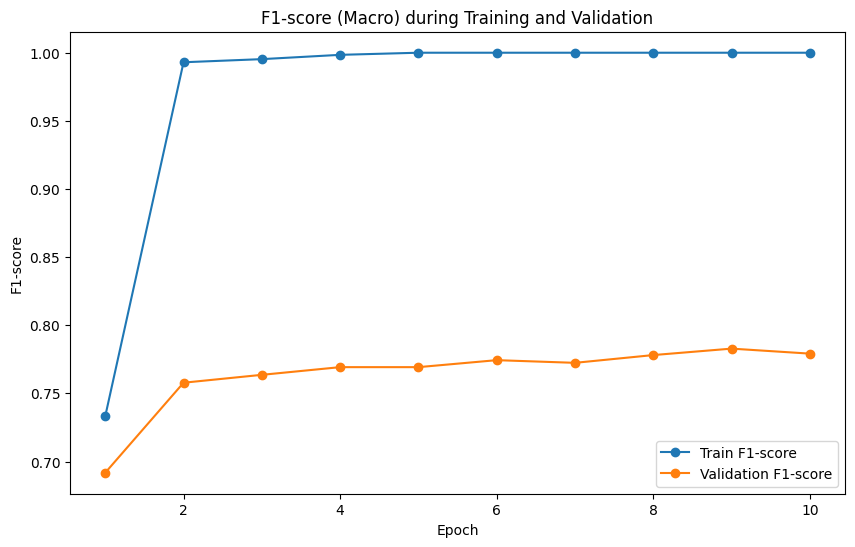

Entraînement terminé ✅


In [83]:
# Nombre d'époques et paramètres pour l'early stopping
epochs = 10
patience = 3 # Nombre d'époques sans amélioration avant l'arrêt anticipé
best_f1 = 0
patience_counter = 0

# Listes pour stocker les F1-scores pour train et val
train_f1_scores = []
val_f1_scores = []

# Mettre le modèle en mode entraînement
model.train()

# Boucle d'entraînement
for epoch in range(epochs):
    total_loss = 0
    correct_preds = 0
    total_preds = 0
    all_labels = []
    all_predictions = []

    # Boucle sur les batches d'entraînement
    for batch in tqdm(train_train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        input_ids, attention_mask, labels = batch
        # Réinitialiser les gradients
        optimizer.zero_grad()

        # Passer les données dans le modèle
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Calcul de la perte
        loss = loss_fn(logits, labels)
        total_loss += loss.item()

        # Rétropropagation et mise à jour des poids
        loss.backward()
        optimizer.step()

        # Calcul des prédictions
        _, predicted_labels = torch.max(logits, dim=1)
        correct_preds += (predicted_labels == labels).sum().item()
        total_preds += labels.size(0)

        # Sauvegarder les labels et prédictions pour calculer le F1 à la fin
        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted_labels.numpy())

    # Calcul de la perte moyenne et de la précision de l'époque
    avg_loss = total_loss / len(train_train_dataloader)
    accuracy = correct_preds / total_preds
    train_f1 = f1_score(all_labels, all_predictions, average='macro')

    # Évaluation sur le jeu de validation
    model.eval()
    val_labels = []
    val_predictions = []
    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Validation Epoch {epoch+1}/{epochs}"):
            input_ids, attention_mask, labels = batch
            

            # Passer les données dans le modèle
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # Calcul des prédictions
            _, predicted_labels = torch.max(logits, dim=1)

            # Sauvegarder les labels et prédictions
            val_labels.extend(labels.numpy())
            val_predictions.extend(predicted_labels.numpy())

    # Calcul du F1-score pour le jeu de validation
    val_f1 = f1_score(val_labels, val_predictions, average='macro')

    # Affichage des résultats pour cette époque
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f} - Train Accuracy: {accuracy:.4f} - Train F1: {train_f1:.4f} - Val F1: {val_f1:.4f}")

    # Enregistrement des F1-scores
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    # Early stopping : vérification de l'amélioration du F1-score sur le jeu de validation
    if val_f1 >= best_f1:
        best_f1 = val_f1
        patience_counter = 0  # Réinitialiser le compteur
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1} due to no improvement in validation F1-score.")
        n=epoch+1
        break

    # Remettre le modèle en mode entraînement pour la prochaine Epochc
    model.train()

# Plot F1-scores pour train et validation
plt.figure(figsize=(10, 6))
plt.plot(range(1, epoch+2), train_f1_scores, label='Train F1-score', marker='o')
plt.plot(range(1, epoch+2), val_f1_scores, label='Validation F1-score', marker='o')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.title('F1-score (Macro) during Training and Validation')
plt.legend()
plt.show()

print("Entraînement terminé ✅")


In [ ]:
# Concaténer les datasets d'entraînement et de validation

# Tokenisation avec barre de chargement
print("Tokenisation train...")
train_encodings = tokenize_with_progress(df_train_full.text, "Tokenisation train")
print("Tokenisation train ✅ ")

# Conversion des labels en tenseurs
train_labels = torch.tensor(df_train_full["label"].map(label_mapping).values, dtype=torch.long)
print("transformation en tenseurs ✅ ")

# Création des datasets
train_dataset = TensorDataset(train_encodings["input_ids"], train_encodings["attention_mask"], train_labels)
print("transformation en datasets ✅ ")

# Création des DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print("transformation en dataloaders ✅ ")

print("Données prétraitées ✅ ")

Tokenisation train...
Tokenisation train ✅ 
transformation en tenseurs ✅ 
transformation en datasets ✅ 
transformation en dataloaders ✅ 
Données prétraitées ✅ 


In [ ]:
# Nombre d'époques et paramètres trouvé avec earlystopping
epochs = 10
# Mettre le modèle en mode entraînement
model.train()

# Boucle d'entraînement
for epoch in range(epochs):
    # Boucle sur les batches d'entraînement
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        input_ids, attention_mask, labels = batch
        # Réinitialiser les gradients
        optimizer.zero_grad()

        # Passer les données dans le modèle
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Calcul de la perte
        loss = loss_fn(logits, labels)
        total_loss += loss.item()

        # Rétropropagation et mise à jour des poids
        loss.backward()
        optimizer.step()


Epoch 3/3: 100%|██████████| 189/189 [12:23<00:00,  3.93s/it]


In [84]:


# Evaluation sur le jeu de test
model.eval()  # Mettre le modèle en mode évaluation
test_labels = []
test_predictions = []

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Testing"):
        input_ids, attention_mask, labels = batch

        # Passer les données dans le modèle
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Calcul des prédictions
        _, predicted_labels = torch.max(logits, dim=1)

        # Sauvegarder les labels et prédictions
        test_labels.extend(labels.numpy())
        test_predictions.extend(predicted_labels.numpy())

# Générer le rapport de classification
report = classification_report(test_labels, test_predictions, target_names=['out_of_scope', 'translate', 'book_flight', 
                                                                            'lost_luggage', 'travel_alert', 'travel_suggestion', 
                                                                            'carry_on', 'book_hotel', 'flight_status'])

# Afficher le rapport de classification
print("Rapport de performance sur le jeu de test :\n")
print(report)


Testing: 100%|██████████| 61/61 [00:46<00:00,  1.30it/s]

Rapport de performance sur le jeu de test :

                   precision    recall  f1-score   support

     out_of_scope       0.78      0.69      0.73        51
        translate       0.89      0.89      0.89         9
      book_flight       0.80      0.95      0.87        21
     lost_luggage       0.69      0.69      0.69        13
     travel_alert       1.00      0.39      0.56        18
travel_suggestion       0.60      0.87      0.71        39
         carry_on       1.00      1.00      1.00        39
       book_hotel       1.00      0.88      0.94        33
    flight_status       0.89      0.85      0.87        20

         accuracy                           0.81       243
        macro avg       0.85      0.80      0.81       243
     weighted avg       0.84      0.81      0.81       243

